# 1- Project Overview
The objective of this notebook is to develop predictive machine learning models capable of estimating the electrical power output of a Combined Cycle Power Plant using environmental operating conditions. Multiple regression models will be developed and evaluated to identify the most accurate approach while providing insights into model performance.

# 2- Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Status update
print("DONE")

DONE


# 3- Load Clean Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zahraatouq/cpp-dataset/clean_power_plant_data.csv")
df.head()

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Power_Output
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


# 3- Define Features and Target

In [3]:
X = df.drop(columns=["Power_Output"])
y = df["Power_Output"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9527, 4)
Target shape: (9527,)


## Observation

The dataset contains four environmental variables that will be used as input features to predict the target variable, Power Output. Separating the features and target variable prepares the dataset for the machine learning modeling process.

# 4- Train-Test Split

In [4]:
random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (7621, 4)
Testing Features: (1906, 4)
Training Target: (7621,)
Testing Target: (1906,)


## Observation

The dataset was split into training and testing subsets using an 80:20 ratio. The training data will be used to build the predictive models, while the testing data will provide an unbiased evaluation of model performance on unseen observations.

# 5- Build Baseline Model

## Linear Regression (Baseline Model)

In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

## Generate Predictions

In [6]:
y_pred = linear_model.predict(X_test)

pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).head(10)

,Actual,Predicted
0,463.57,462.518984
1,441.31,446.678196
2,445.34,447.957702
3,465.42,467.443596
4,439.06,434.679907
5,442.02,446.766206
6,471.48,476.953696
7,478.34,478.093666
8,445.90,448.055785
9,464.18,463.091601


## Model Evaluation

In [7]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 3.62
RMSE: 4.59
R²  : 0.9284


## Observations and Business Interpretation
The Linear Regression model achieved a Mean Absolute Error (MAE) of 3.62 MW and a Root Mean Squared Error (RMSE) of 4.59 MW. The model also obtained an R² score of 0.9284, indicating that approximately 92.8% of the variation in power output can be explained by the environmental variables included in the model.

The baseline model demonstrates strong predictive performance despite its simplicity. The relatively small prediction errors and high R² score indicate that the selected environmental variables provide substantial information for estimating plant power output. This model establishes a reliable benchmark for evaluating more advanced machine learning algorithms.

## Actual vs Predicted Values

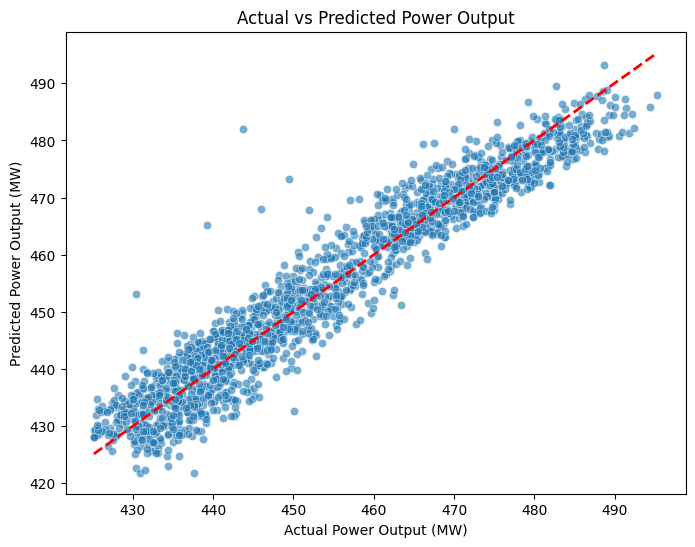

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("Actual vs Predicted Power Output")

plt.show()

## Observation

The Actual vs Predicted plot shows that most predictions are closely aligned with the ideal prediction line, indicating that the Linear Regression model is able to estimate Power Output values with high accuracy across the observed range.

The model successfully captures the full range of plant power generation, from lower output levels around 420 MW to higher production levels approaching 495 MW. However, a small number of observations deviate from the ideal line, particularly within the mid-range output values, indicating cases where the model produces larger prediction errors.

Overall, the visualization confirms the strong performance observed from the evaluation metrics and demonstrates that the baseline model provides reliable predictions.

## Residual Analysis

In [9]:
residuals = y_test - y_pred

residuals.head()

1087    1.051016
6308   -5.368196
8021   -2.617702
9483   -2.023596
4459    4.380093
Name: Power_Output, dtype: float64

## Residual Distribution

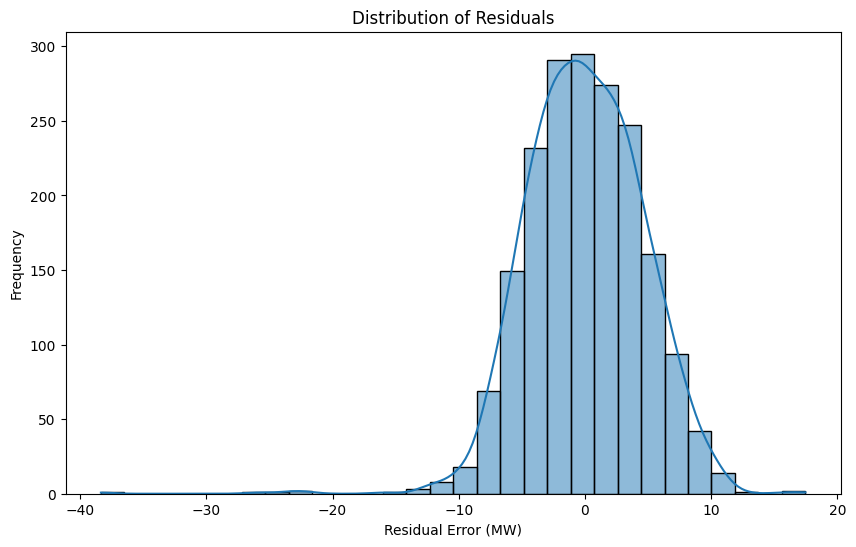

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual Error (MW)")
plt.ylabel("Frequency")

plt.show()

## Observation and Business Interpretation

The residual distribution appears approximately centered around zero, indicating that the Linear Regression model does not show a strong systematic bias in its predictions.

Most residual values are concentrated within a relatively narrow range around zero, suggesting that the majority of predictions are close to the actual power output values. This behavior is consistent with the strong evaluation metrics achieved by the model.

A small number of observations extend toward larger negative residual values, representing cases where the model overestimated the actual power output. These deviations appear limited compared with the overall distribution.

The residual analysis indicates that the baseline model provides stable predictions across most operating conditions. However, the presence of some larger prediction errors suggests that certain operating conditions may involve more complex patterns that cannot be fully captured by a linear approach. Therefore, evaluating more advanced machine learning models may help improve prediction accuracy by capturing potential non-linear relationships between environmental conditions and power generation.